<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/01_regularization_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 01 — Regularization Techniques in TensorFlow/Keras

## What This Notebook Covers
We build a neural network that deliberately overfits, then apply regularization techniques one by one, comparing each with an **A/B test** (with vs. without). Every technique is explained before the code.

**Techniques covered:**
- L1 Regularization (Lasso)
- L2 Regularization (Ridge / Weight Decay)
- Dropout
- Early Stopping

**Dataset:** Fashion-MNIST (10-class clothing classification)


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print('TF version:', tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

TF version: 2.20.0


## 1. Load & Preprocess Data

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train, X_valid = X_train_full[5000:], X_train_full[:5000]
y_train, y_valid = y_train_full[5000:], y_train_full[:5000]

print(f'Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (55000, 28, 28), Valid: (5000, 28, 28), Test: (10000, 28, 28)


## 2. Helper: Training & Plotting

We define a reusable function to train any model and plot its learning curves.
This is the core of our A/B testing approach — same function, different model.

In [3]:
def train_and_plot(model_a, model_b, label_a='Baseline', label_b='Regularized',
                   epochs=30, callbacks_b=None):
    """Train two models and compare their learning curves side by side."""
    for m in [model_a, model_b]:
        m.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history_a = model_a.fit(X_train, y_train,
                            validation_data=(X_valid, y_valid),
                            epochs=epochs, verbose=0)

    history_b = model_b.fit(X_train, y_train,
                            validation_data=(X_valid, y_valid),
                            epochs=epochs, verbose=0,
                            callbacks=callbacks_b or [])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric, title in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
        ax.plot(history_a.history[metric],         label=f'{label_a} train', linestyle='--', color='steelblue')
        ax.plot(history_a.history[f'val_{metric}'], label=f'{label_a} val',   color='steelblue')
        ax.plot(history_b.history[metric],         label=f'{label_b} train', linestyle='--', color='tomato')
        ax.plot(history_b.history[f'val_{metric}'], label=f'{label_b} val',   color='tomato')
        ax.set_title(title)
        ax.legend(fontsize=7)
        ax.set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()

    val_acc_a = max(history_a.history['val_accuracy'])
    val_acc_b = max(history_b.history['val_accuracy'])
    print(f'{label_a} best val accuracy:  {val_acc_a:.4f}')
    print(f'{label_b} best val accuracy: {val_acc_b:.4f}')

print('Helper function defined.')

Helper function defined.


## 3. A/B Test: L2 Regularization (Weight Decay)

### How L2 Works
L2 adds a penalty of `lambda * sum(w^2)` to the loss. This discourages any single weight
from becoming very large, producing a smoother model that generalizes better.

- Applied via `kernel_regularizer=tf.keras.regularizers.l2(0.01)`
- Too large lambda -> underfitting; too small -> no effect


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


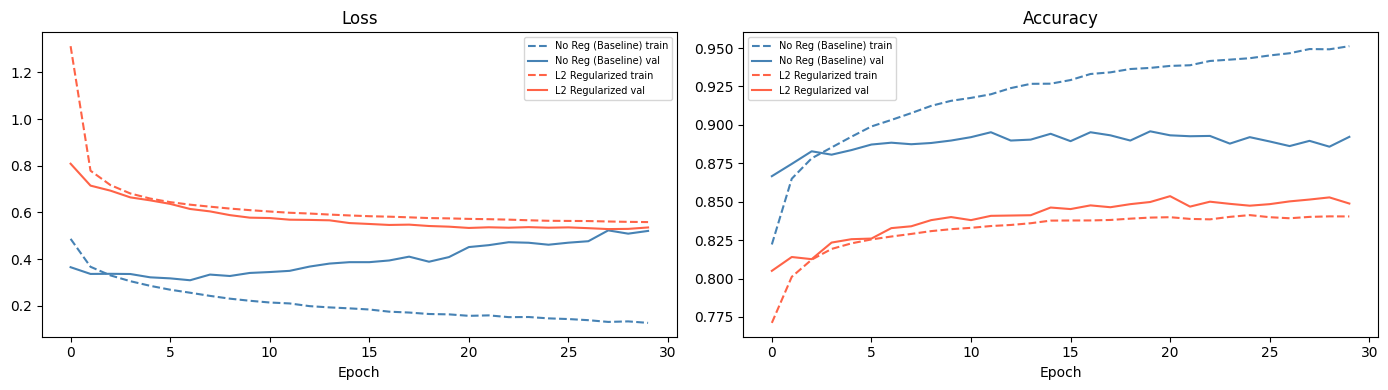

No Reg (Baseline) best val accuracy:  0.8958
L2 Regularized best val accuracy: 0.8536


In [4]:
def make_baseline():
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu'),
        tf.keras.layers.Dense(200, activation='relu'),
        tf.keras.layers.Dense(100, activation='relu'),
        tf.keras.layers.Dense(10,  activation='softmax'),
    ])

def make_l2_model():
    reg = tf.keras.regularizers.l2(0.01)
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dense(200, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dense(100, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dense(10,  activation='softmax'),
    ])

train_and_plot(make_baseline(), make_l2_model(),
               label_a='No Reg (Baseline)', label_b='L2 Regularized')

## 4. A/B Test: L1 Regularization (Lasso)

### How L1 Works
L1 adds a penalty of `lambda * sum(|w|)`. This encourages **sparse** networks —
many weights go to exactly zero. Useful when only a few features truly matter.


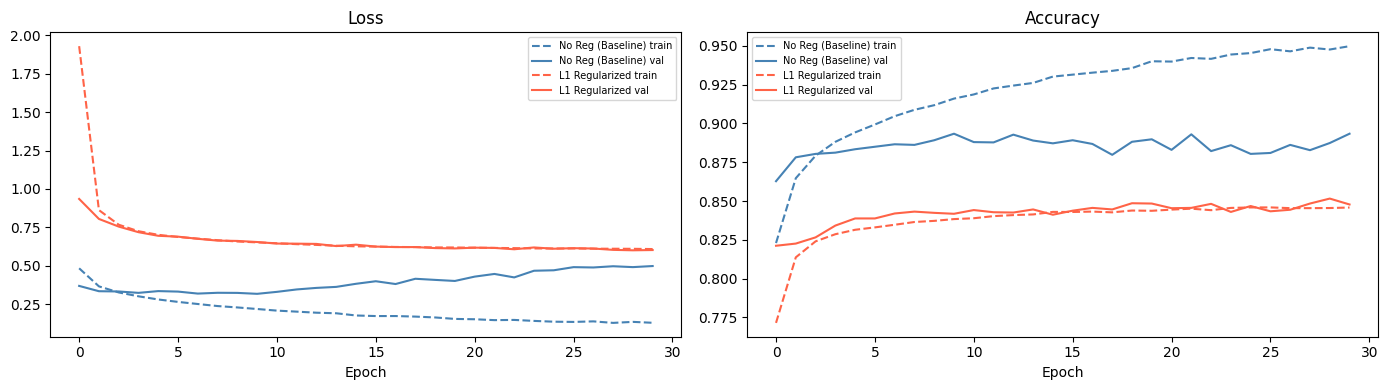

No Reg (Baseline) best val accuracy:  0.8934
L1 Regularized best val accuracy: 0.8516


In [5]:
def make_l1_model():
    reg = tf.keras.regularizers.l1(0.001)
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dense(200, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dense(100, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dense(10,  activation='softmax'),
    ])

train_and_plot(make_baseline(), make_l1_model(),
               label_a='No Reg (Baseline)', label_b='L1 Regularized')

## 5. A/B Test: Dropout

### How Dropout Works
During each training step, dropout randomly sets a fraction `rate` of neuron outputs to zero.
This prevents neurons from co-adapting and forces the network to learn redundant representations.
Keras automatically disables dropout at inference time.


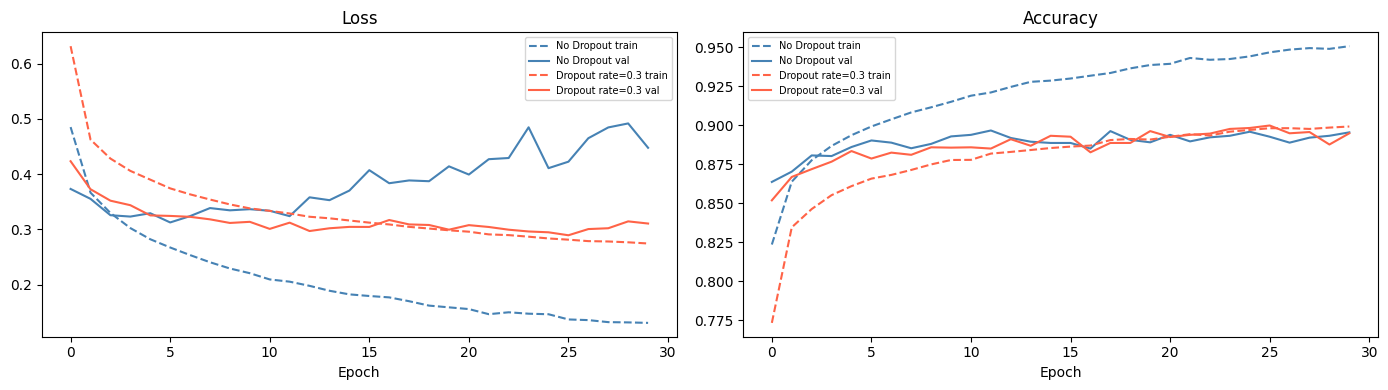

No Dropout best val accuracy:  0.8966
Dropout rate=0.3 best val accuracy: 0.8998


In [6]:
def make_dropout_model(rate=0.3):
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu'),
        tf.keras.layers.Dropout(rate),
        tf.keras.layers.Dense(200, activation='relu'),
        tf.keras.layers.Dropout(rate),
        tf.keras.layers.Dense(100, activation='relu'),
        tf.keras.layers.Dropout(rate),
        tf.keras.layers.Dense(10,  activation='softmax'),
    ])

train_and_plot(make_baseline(), make_dropout_model(),
               label_a='No Dropout', label_b='Dropout rate=0.3')

## 6. A/B Test: Early Stopping

### How Early Stopping Works
Instead of running for a fixed number of epochs, we watch the validation loss.
If it has not improved after `patience` epochs, training stops.
`restore_best_weights=True` reverts the model to the best checkpoint automatically.


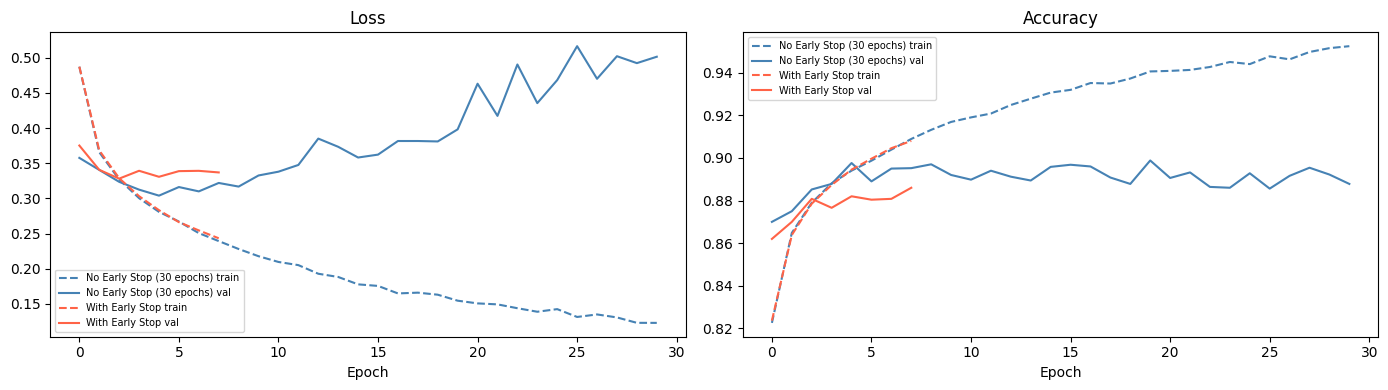

No Early Stop (30 epochs) best val accuracy:  0.8988
With Early Stop best val accuracy: 0.8860


In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

train_and_plot(make_baseline(), make_baseline(),
               label_a='No Early Stop (30 epochs)',
               label_b='With Early Stop',
               epochs=30,
               callbacks_b=[early_stop])

## 7. Combining All Techniques

In practice, L2 + Dropout + Early Stopping are complementary and used together.



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 42: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 47: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


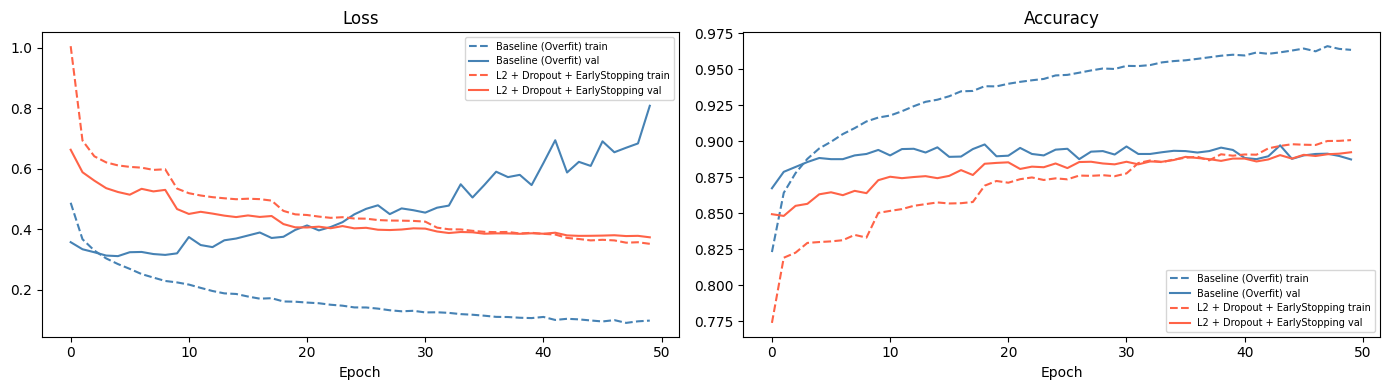

Baseline (Overfit) best val accuracy:  0.8978
L2 + Dropout + EarlyStopping best val accuracy: 0.8924


In [8]:
def make_best_model():
    reg = tf.keras.regularizers.l2(0.001)
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(200, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(100, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10,  activation='softmax'),
    ])

combined_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
]

train_and_plot(make_baseline(), make_best_model(),
               label_a='Baseline (Overfit)',
               label_b='L2 + Dropout + EarlyStopping',
               epochs=50,
               callbacks_b=combined_callbacks)

## Summary

| Technique | Best Used When | Typical Values |
|---|---|---|
| L1 | Sparse features suspected | lambda = 0.0001 to 0.01 |
| L2 | General purpose, tabular data | lambda = 0.0001 to 0.01 |
| Dropout | Large networks, image/text | rate = 0.2 to 0.5 |
| Early Stop | Always — free regularization | patience = 5 to 20 |

Next: **Notebook 02** — Same techniques in PyTorch
